In [3]:
import yfinance as yf
import numpy as np
import matplotlib.pyplot as plt 

FUNDS = [
    'SPY', 'IEF', 'TLT', 'NVDA', 'QQQ', 'VNQ',
    'XLE', 'EEM', 'XLP', 'GLD', 'AGG', 'VIXY',
]

df = yf.download(
    FUNDS,
    start='2015-01-01',
    end='2016-01-01',
    progress=False,
    auto_adjust=True
)['Close'].dropna()

# Changed 'prices' to 'df'
log_prices = np.log(df)
log_rets = log_prices.diff().dropna()

# Changed 'prices' to 'df'
print(df.shape)
print(log_rets.head())

(252, 12)
Ticker           AGG       EEM       GLD       IEF      NVDA       QQQ  \
Date                                                                     
2015-01-05  0.002171 -0.017957  0.014965  0.006083 -0.017034 -0.014777   
2015-01-06  0.002526 -0.004211  0.011334  0.006695 -0.030788 -0.013499   
2015-01-07 -0.000180  0.021394 -0.005909 -0.000186 -0.002609  0.012808   
2015-01-08 -0.001534  0.016893 -0.004217 -0.004087  0.036927  0.018959   
2015-01-09  0.002435 -0.003305  0.011321  0.004921  0.004021 -0.006605   

Ticker           SPY       TLT      VIXY       VNQ       XLE       XLP  
Date                                                                    
2015-01-05 -0.018225  0.015586  0.072061  0.005458 -0.042248 -0.007057  
2015-01-06 -0.009464  0.017857  0.021439  0.009870 -0.014799 -0.001251  
2015-01-07  0.012384 -0.001977 -0.033703  0.015215  0.002128  0.016957  
2015-01-08  0.017589 -0.013332 -0.066124  0.003768  0.022201  0.015059  
2015-01-09 -0.008046  0.010893  0

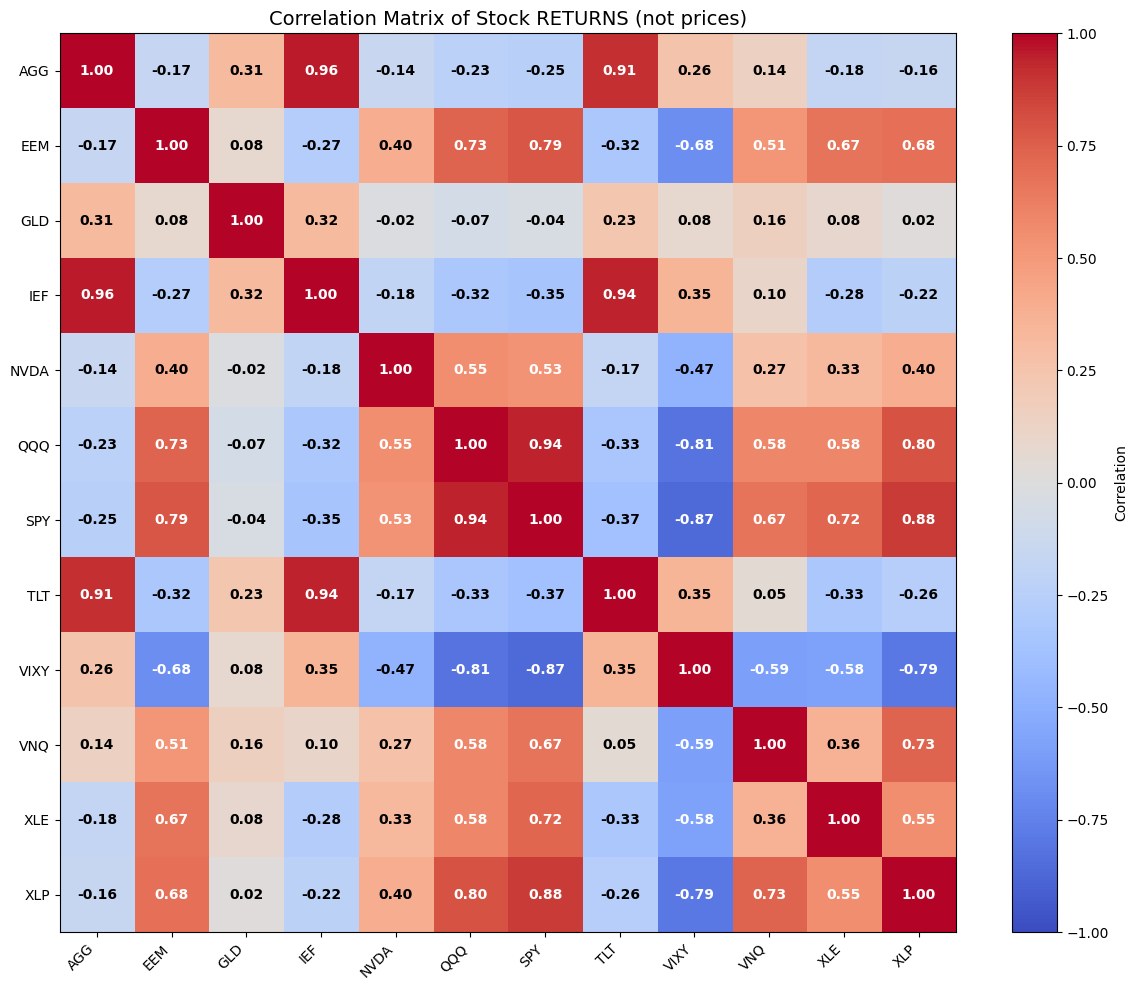

Average correlation between stocks: 0.129


In [4]:
# Step 1: Make sure you have RETURNS, not prices
if 'Date' in df.columns:
    prices = df.drop('Date', axis=1)
else:
    prices = df.copy()

returns = prices.pct_change().dropna()
correlation_matrix = returns.corr()

# Step 2: Plot heatmap
plt.figure(figsize=(12, 10))
im = plt.imshow(correlation_matrix, cmap='coolwarm', aspect='auto', vmin=-1, vmax=1)
plt.colorbar(im, label='Correlation')

# Step 3: Add text annotations with smart color
for i in range(len(correlation_matrix)):
    for j in range(len(correlation_matrix)):
        value = correlation_matrix.iloc[i, j]
        color = 'white' if abs(value) > 0.5 else 'black'
        plt.text(j, i, f'{value:.2f}', ha='center', va='center', 
                color=color, fontsize=10, fontweight='bold')

# Step 4: Format axes
plt.xticks(range(len(correlation_matrix)), correlation_matrix.columns, rotation=45, ha='right')
plt.yticks(range(len(correlation_matrix)), correlation_matrix.columns)
plt.title('Correlation Matrix of Stock RETURNS (not prices)', fontsize=14)
plt.tight_layout()
plt.show()

# Step 5: Calculate average correlation (your math was correct!)
n = len(correlation_matrix)
avg_correlation = (correlation_matrix.values.sum() - n) / (n * (n - 1))
print(f"Average correlation between stocks: {avg_correlation:.3f}")